# Демонстрация онлайн-планирования

Демонстрация работы онлайн-агента для адаптации графиков смен водителей при возникновении возмущений (пробок).

**Сценарий:** обученный offline-агент формирует базовое расписание. Затем задаётся сценарий возмущения (увеличение времени
движения по линиям маршрута), и online-агент формирует обновлённое расписание с учётом задержек.

## 1. Импорт библиотек

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from src.config import (
    load_environment_config,
    load_ppo_agent_config,
    load_online_scenario_config,
)
from src.environment import Environment
from src.ppo import PPOAgent
from src.models import Trip, Lunch, Shift, Route

## 2. Загрузка конфигураций

In [2]:
CONFIG_DIR = "src/config"

env_config = load_environment_config(f"{CONFIG_DIR}/environment.yaml")
agent_config = load_ppo_agent_config(f"{CONFIG_DIR}/ppo_agent.yaml")
online_scenario = load_online_scenario_config(f"{CONFIG_DIR}/online_scenario.yaml")

print("=== Environment Config ===")
print(env_config)
print()
print("=== Online Scenario ===")
print(f"Offline checkpoint: {online_scenario.offline_checkpoint_path}")
for d in online_scenario.disturbances:
    print(f"  Возмущение: {d.kind}, line_id={d.line_id}, "
          f"{d.start_minute}-{d.end_minute} мин, задержка={d.delay_minutes} мин")

=== Environment Config ===
EnvironmentConfig(shifts=ShiftsConfig(shift_duration=480, work_duration_before_lunch=240, lunch_duration=45, min_rest_duration=3), control_points=ControlPointsConfig(short_term_horizon=300), target_bus_set_size=8, reward=RewardConfig(final_buses=4.0, final_deadhead=0.1, step_unused_penalty=4.0, step_deadhead_penalty=0.1, step_rest_reward=2.5, step_demand_penalty=1.0), bus_fleet_size=260, schedule_data_path='../../data/schedule_obninsk.json', time_window_minutes=60.0, disturbances=[])

=== Online Scenario ===
Offline checkpoint: checkpoints/ppo_offline_best_obninsk/best.pt
  Возмущение: interval_delay, line_id=l1, 540-720 мин, задержка=15.0 мин
  Возмущение: interval_delay, line_id=l2, 540-720 мин, задержка=15.0 мин
  Возмущение: interval_delay, line_id=l3, 540-720 мин, задержка=15.0 мин
  Возмущение: interval_delay, line_id=l4, 540-720 мин, задержка=15.0 мин
  Возмущение: interval_delay, line_id=l5, 540-720 мин, задержка=15.0 мин
  Возмущение: interval_delay,

## 3. Утилита: диаграмма Ганта

In [3]:
def plot_gantt(shifts, routes, title="Диаграмма Ганта: смены водителей"):
    """Диаграмма Ганта для водительских смен."""
    # Маппинг line_id -> (route_name, direction)
    line_to_route = {}
    for route in routes:
        line_to_route[route.line_id_A] = (route.name, "A")
        line_to_route[route.line_id_B] = (route.name, "B")

    # Палитра цветов для маршрутов
    route_names = sorted(set(r.name for r in routes))
    base_cmap = plt.cm.get_cmap("tab10", len(route_names))
    route_colors = {}
    for i, name in enumerate(route_names):
        base_color = np.array(base_cmap(i))
        route_colors[(name, "A")] = tuple(base_color)
        lighter = base_color * 0.6 + np.array([0.4, 0.4, 0.4, 0.0])
        lighter[3] = 1.0
        route_colors[(name, "B")] = tuple(lighter)

    lunch_color = "#AAAAAA"

    fig, ax = plt.subplots(figsize=(22, max(8, len(shifts) * 0.55)))
    ax.set_facecolor("#EAEAF2")

    y_labels = []
    for i, shift in enumerate(shifts):
        y = i
        y_labels.append(shift.bus_id)

        for event in shift.events:
            if isinstance(event, Trip):
                route_info = line_to_route.get(event.line_id)
                if route_info is None:
                    color = "gray"
                    label_text = event.line_id
                else:
                    route_name, direction = route_info
                    color = route_colors[(route_name, direction)]
                    label_text = f"{route_name}-{direction}"

                duration = event.end_time - event.start_time
                ax.barh(
                    y, duration, left=event.start_time,
                    height=0.7, color=color, edgecolor="black", linewidth=0.5,
                )
                if duration > 15:
                    ax.text(
                        event.start_time + duration / 2, y, label_text,
                        ha="center", va="center", fontsize=14,
                        fontweight="bold", color="white",
                    )

            elif isinstance(event, Lunch):
                duration = event.end_time - event.start_time
                ax.barh(
                    y, duration, left=event.start_time,
                    height=0.7, color=lunch_color, edgecolor="black", linewidth=0.5,
                )
                ax.text(
                    event.start_time + duration / 2, y, "L",
                    ha="center", va="center", fontsize=14,
                    fontweight="bold", color="white",
                )

    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels, fontsize=14)
    ax.tick_params(axis="x", labelsize=14)
    ax.set_xlabel("Время (мин)", fontsize=14)
    ax.set_title(title, fontsize=14)
    ax.invert_yaxis()

    ax.grid(True, axis="x", color="white", linewidth=0.8)
    ax.set_axisbelow(True)
    for yi in range(len(y_labels)):
        ax.axhline(y=yi - 0.5, color="white", linewidth=0.5)
    ax.axhline(y=len(y_labels) - 0.5, color="white", linewidth=0.5)

    legend_handles = []
    for name in route_names:
        color_a = route_colors[(name, "A")]
        color_b = route_colors[(name, "B")]
        legend_handles.append(mpatches.Patch(color=color_a, label=f"{name}-A"))
        legend_handles.append(mpatches.Patch(color=color_b, label=f"{name}-B"))
    legend_handles.append(mpatches.Patch(color=lunch_color, label="L"))
    ax.legend(
        handles=legend_handles, loc="upper right",
        fontsize=9, ncol=2, title="Bus line", title_fontsize=10,
    )

    plt.tight_layout()
    plt.show()

## 4. Запуск offline-агента (базовое расписание)

In [4]:
# Создать offline-окружение и загрузить обученного агента
env_offline = Environment(env_config, mode="offline")
offline_agent = PPOAgent(agent_config, env_offline.state_dim(), env_offline.action_dim())
offline_agent.load(online_scenario.offline_checkpoint_path)
offline_agent.policy.eval()

# Детерминистический запуск
obs = env_offline.reset()
done = False
while not done:
    action, _, _ = offline_agent.act(obs, env_offline.action_mask, deterministic=True)
    obs, _, done, _ = env_offline.step(action)

analytics_offline = env_offline.get_analytics()
shifts_offline = env_offline.get_shifts()
routes_info = env_offline.get_routes_info()

print("=== Результат offline-агента (без возмущений) ===")
print(f"Автобусов задействовано: {analytics_offline.total_bus_used}")
print(f"Холостой пробег: {analytics_offline.total_deadhead_time:.1f} мин")
print(f"Accumulated reward: {analytics_offline.accumulated_reward:.2f}")
print(f"Final reward: {analytics_offline.final_reward:.2f}")

=== Результат offline-агента (без возмущений) ===
Автобусов задействовано: 36
Холостой пробег: 217.0 мин
Accumulated reward: 247.97
Final reward: -165.70


[Shift(bus_id='bus-0', departure_time=250.0, events=[Trip(line_id='l5', start_time=250.0, end_time=284.0), Trip(line_id='l6', start_time=305.0, end_time=344.0), Trip(line_id='l5', start_time=347.0, end_time=381.0), Trip(line_id='l6', start_time=394.0, end_time=433.0), Trip(line_id='l5', start_time=436.0, end_time=470.0), Trip(line_id='l6', start_time=478.0, end_time=517.0), Lunch(cp_id='CP-0', start_time=519.0, end_time=564.0), Trip(line_id='l5', start_time=564.0, end_time=598.0), Trip(line_id='l6', start_time=615.0, end_time=654.0), Trip(line_id='l5', start_time=657.0, end_time=691.0)]), Shift(bus_id='bus-52', departure_time=280.0, events=[Trip(line_id='l2', start_time=280.0, end_time=311.0), Trip(line_id='l1', start_time=345.0, end_time=375.0), Trip(line_id='l2', start_time=378.0, end_time=409.0), Trip(line_id='l5', start_time=422.0, end_time=456.0), Trip(line_id='l6', start_time=465.0, end_time=504.0), Trip(line_id='l1', start_time=509.0, end_time=539.0), Lunch(cp_id='CP-1', start_t

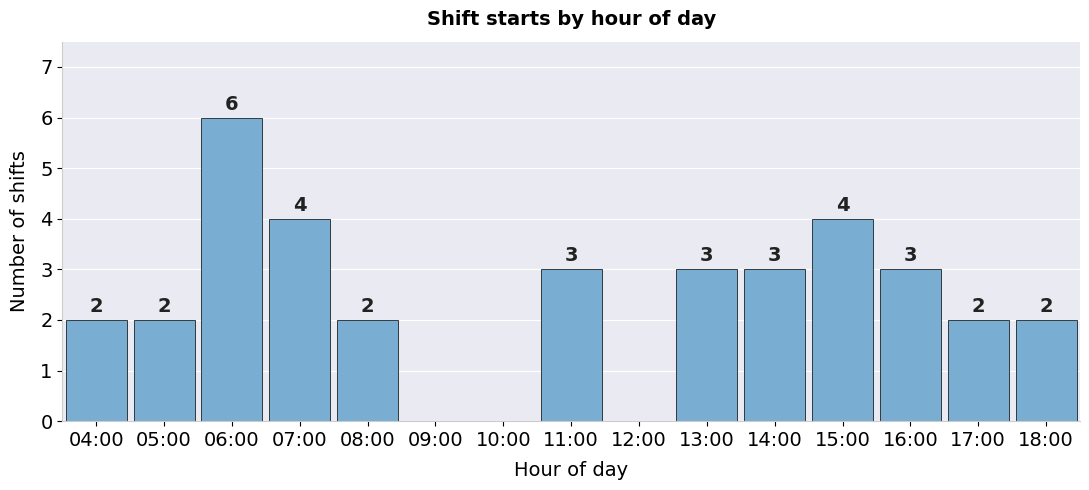

Done


In [55]:


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

departure_times = [
    250.0, 280.0, 335.0, 355.0, 370.0, 375.0, 380.0, 385.0, 405.0, 408.0,
    433.0, 435.0, 438.0, 445.0, 520.0, 535.0, 676.0, 702.0, 705.0, 818.0,
    830.0, 830.0, 858.0, 881.0, 882.0, 900.0, 903.0, 916.0, 925.0, 969.0,
    1000.0, 1004.0, 1050.0, 1050, 1110, 1113.0
]

hour_counts = {}
for t in departure_times:
    h = int(t) // 60
    hour_counts[h] = hour_counts.get(h, 0) + 1

min_h, max_h = min(hour_counts), max(hour_counts)
hours = np.arange(min_h, max_h + 1)
counts = np.array([hour_counts.get(h, 0) for h in hours])

fig, ax = plt.subplots(figsize=(11, 5))

colors = ['#79ADD2' if c > 0 else '#d9d9d9' for c in counts]
bars = ax.bar(hours, counts, color=colors, width=0.9, edgecolor='black', linewidth=0.5)

for bar, count in zip(bars, counts):
    if count > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.08,
                str(count), ha='center', va='bottom', fontsize=14, fontweight='bold', color='#222')

ax.set_facecolor("#EAEAF2")
ax.set_xlabel('Hour of day', fontsize=14, labelpad=8)
ax.set_ylabel('Number of shifts', fontsize=14, labelpad=8)
ax.set_title('Shift starts by hour of day', fontsize=14, fontweight='bold', pad=12)

ax.set_xticks(hours)
ax.set_xticklabels([f"{h:02d}:00" for h in hours], fontsize=14)
ax.set_xlim(min_h - 0.5, max_h + 0.5)
ax.set_ylim(0, max(counts) + 1.5)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.tick_params(axis='y', labelsize=14)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#ccc')
ax.spines['bottom'].set_color('#ccc')
ax.yaxis.grid(True, linestyle='-', alpha=1.0, color='#fff')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('shift_dist.png', dpi=150, bbox_inches='tight')

plt.show()
print("Done")

### Диаграмма Ганта: offline-результат

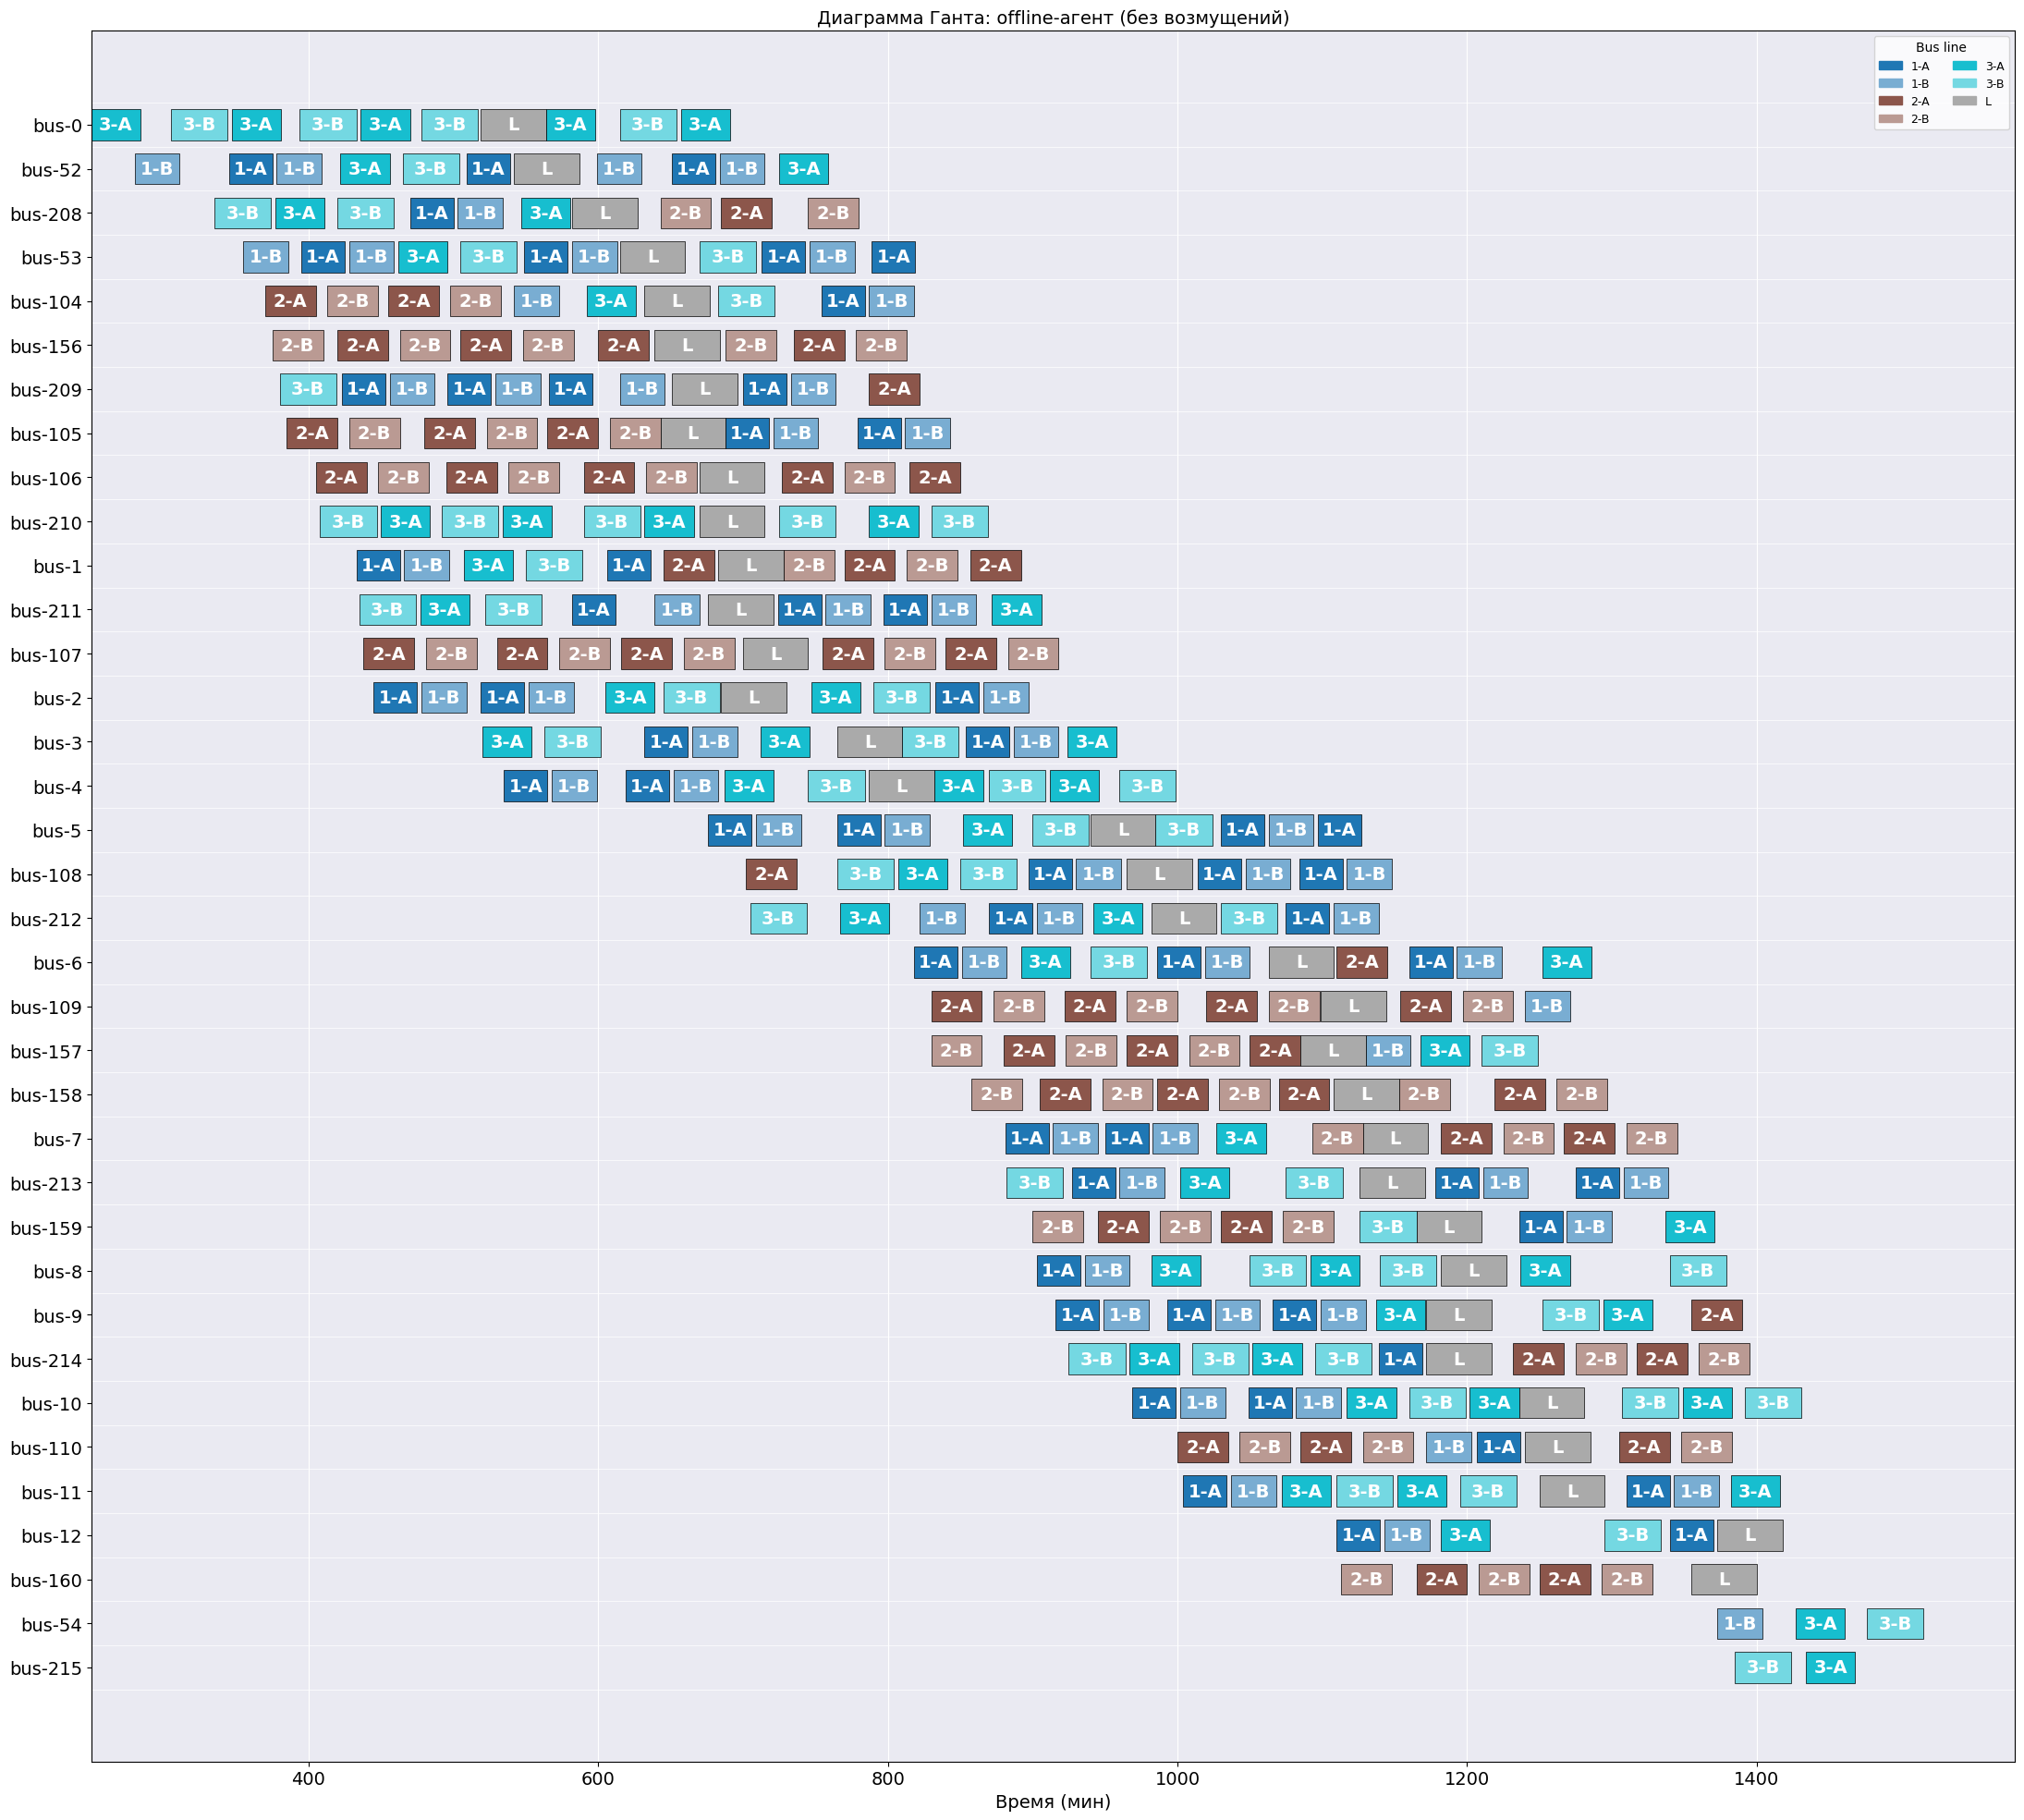

In [5]:
plot_gantt(shifts_offline, routes_info, title="Диаграмма Ганта: offline-агент (без возмущений)")

## 5. Сценарий возмущения

Задаём сценарий через конфигурацию `online_scenario.yaml`.
Возмущения увеличивают время движения по линиям маршрута в указанном временном интервале.

In [6]:
print("=== Сценарий возмущения ===")
for d in online_scenario.disturbances:
    line_desc = d.line_id if d.line_id else "все линии"
    start_h = d.start_minute / 60 if d.start_minute else "?"
    end_h = d.end_minute / 60 if d.end_minute else "?"
    print(f"  Линия: {line_desc}")
    print(f"  Интервал: {start_h:.1f}ч - {end_h:.1f}ч ({d.start_minute}-{d.end_minute} мин)")
    print(f"  Задержка: +{d.delay_minutes} мин к времени движения")
    print()

=== Сценарий возмущения ===
  Линия: l1
  Интервал: 9.0ч - 12.0ч (540-720 мин)
  Задержка: +15.0 мин к времени движения

  Линия: l2
  Интервал: 9.0ч - 12.0ч (540-720 мин)
  Задержка: +15.0 мин к времени движения

  Линия: l3
  Интервал: 9.0ч - 12.0ч (540-720 мин)
  Задержка: +15.0 мин к времени движения

  Линия: l4
  Интервал: 9.0ч - 12.0ч (540-720 мин)
  Задержка: +15.0 мин к времени движения

  Линия: l5
  Интервал: 9.0ч - 12.0ч (540-720 мин)
  Задержка: +15.0 мин к времени движения

  Линия: l6
  Интервал: 9.0ч - 12.0ч (540-720 мин)
  Задержка: +15.0 мин к времени движения



## 6. Запуск online-агента (с возмущениями)

In [7]:
# Создать online-окружение с возмущениями
env_config_online = load_environment_config(f"{CONFIG_DIR}/environment.yaml")
env_config_online.disturbances = online_scenario.disturbances

env_online = Environment(env_config_online, mode="online")

# Online-агент (используем offline-чекпоинт)
online_agent = PPOAgent(agent_config, env_online.state_dim(), env_online.action_dim())
online_agent.load(online_scenario.offline_checkpoint_path)
online_agent.policy.eval()

# Привязать offline-политику для планировщика холостых поездок
planner_agent = PPOAgent(agent_config, env_online.state_dim(), env_online.action_dim())
planner_agent.load(online_scenario.offline_checkpoint_path)
planner_agent.policy.eval()
env_online.attach_deadhead_policy(planner_agent)

# Детерминистический запуск
obs = env_online.reset()
done = False
while not done:
    action, _, _ = online_agent.act(obs, env_online.action_mask, deterministic=True)
    obs, _, done, _ = env_online.step(action)

analytics_online = env_online.get_analytics()
shifts_online = env_online.get_shifts()

print("=== Результат online-агента (с возмущениями) ===")
print(f"Автобусов задействовано: {analytics_online.total_bus_used}")
print(f"Холостой пробег: {analytics_online.total_deadhead_time:.1f} мин")
print(f"Accumulated reward: {analytics_online.accumulated_reward:.2f}")
print(f"Final reward: {analytics_online.final_reward:.2f}")

=== Результат online-агента (с возмущениями) ===
Автобусов задействовано: 44
Холостой пробег: 117.0 мин
Accumulated reward: 321.30
Final reward: -187.70


## 7. Сравнение результатов

In [8]:
print(f"{'Метрика':<30} {'Offline':>12} {'Online':>12} {'Разница':>12}")
print("-" * 70)
print(f"{'Автобусов':<30} {analytics_offline.total_bus_used:>12} {analytics_online.total_bus_used:>12} {analytics_online.total_bus_used - analytics_offline.total_bus_used:>+12}")
print(f"{'Холостой пробег (мин)':<30} {analytics_offline.total_deadhead_time:>12.1f} {analytics_online.total_deadhead_time:>12.1f} {analytics_online.total_deadhead_time - analytics_offline.total_deadhead_time:>+12.1f}")
print(f"{'Accumulated reward':<30} {analytics_offline.accumulated_reward:>12.2f} {analytics_online.accumulated_reward:>12.2f} {analytics_online.accumulated_reward - analytics_offline.accumulated_reward:>+12.2f}")
print(f"{'Final reward':<30} {analytics_offline.final_reward:>12.2f} {analytics_online.final_reward:>12.2f} {analytics_online.final_reward - analytics_offline.final_reward:>+12.2f}")

Метрика                             Offline       Online      Разница
----------------------------------------------------------------------
Автобусов                                36           41           +5
Холостой пробег (мин)                 217.0        102.0       -115.0
Accumulated reward                   247.97       354.30      +106.33
Final reward                        -165.70      -174.20        -8.50


### Диаграмма Ганта: online-результат

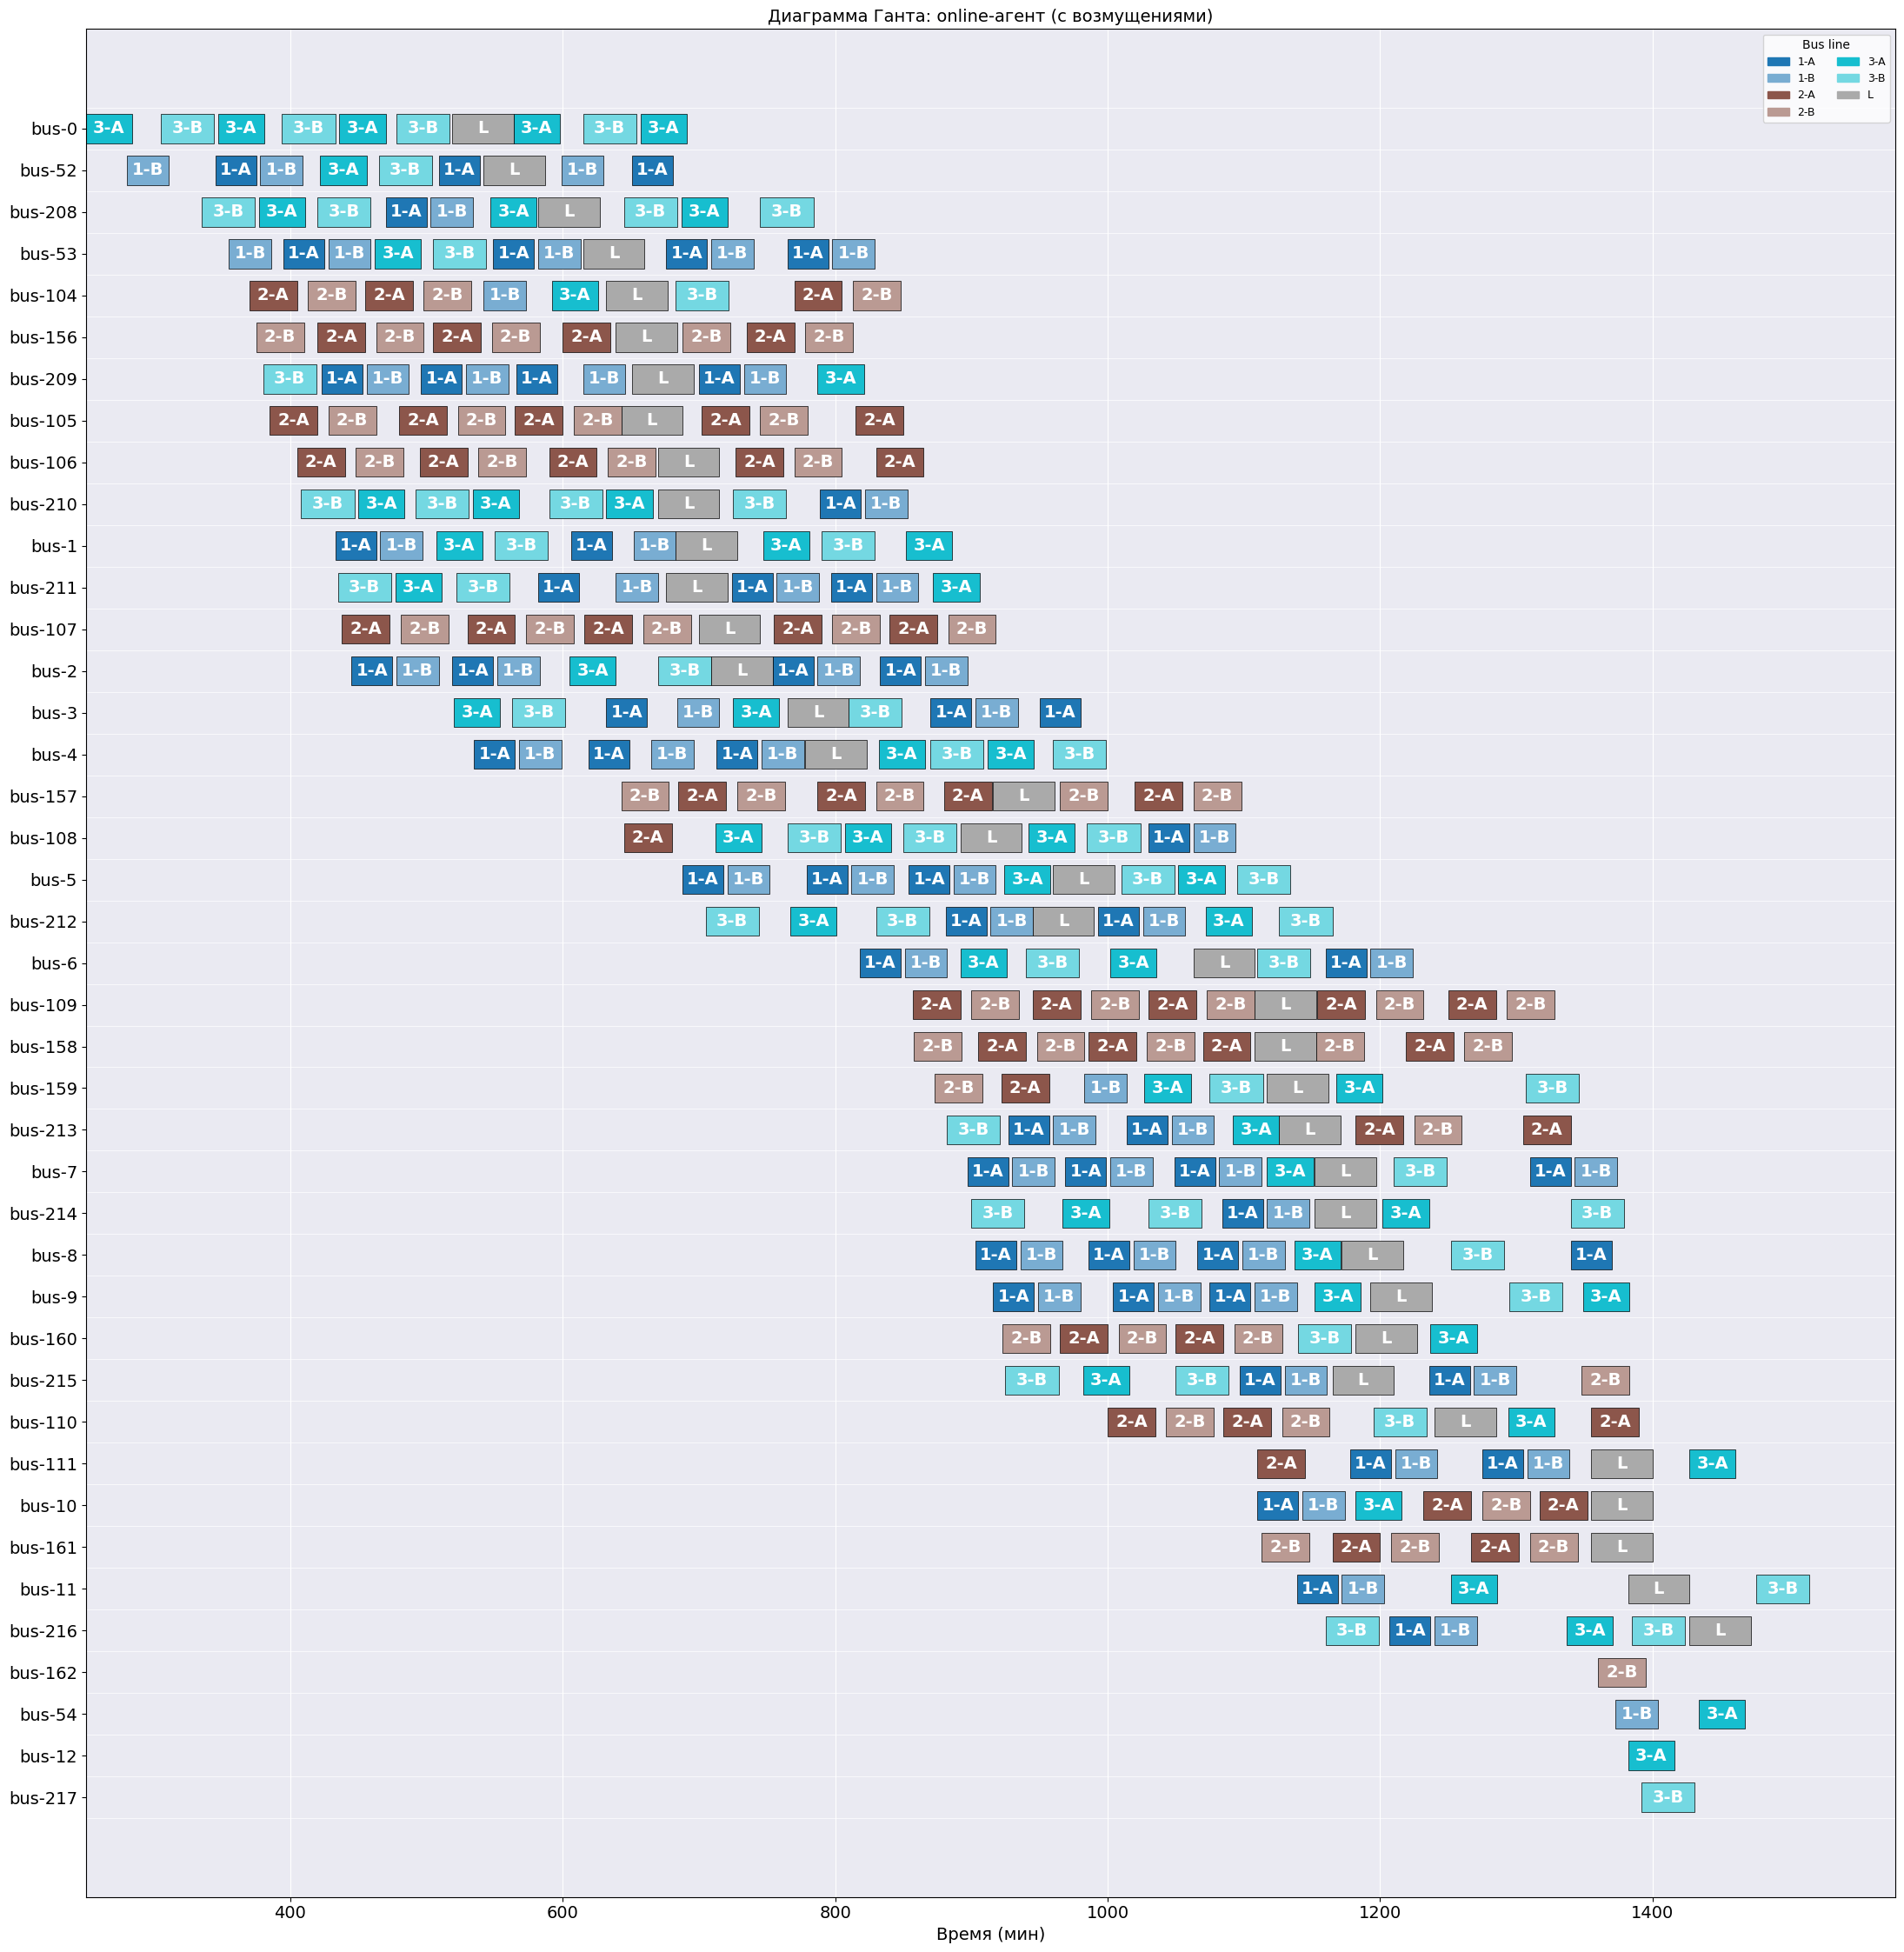

In [10]:
shifts_offline = env_online.get_shifts()
routes_info = env_online.get_routes_info()
plot_gantt(shifts_online, routes_info, title="Диаграмма Ганта: online-агент (с возмущениями)")